### 학습된 대형모델(백본)인 MobileNet v2 전이학습 하여 cifat10  dataset 을 분류하기
- 전이학습(Transfer Learning)
  - 이미 학습된 모델을 일부 재학습 하여 내가 가진 새 데이터에 활용함
---
Conv Layer  <- exception 영역<br>
Dense Layer < - classification 영역(top영역) : 이 부분을 수정해서 사용

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
(x_train, y_train),(x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# one hot
NUM_CLASESS = 10
y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASESS)
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASESS)

print(f'train data : {x_train.shape}, {y_train.shape}') # (50000, 32, 32, 3), (50000, 10)
print(f'test data : {x_test.shape}, {y_test.shape}')    # (10000, 32, 32, 3), (10000, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
train data : (50000, 32, 32, 3), (50000, 10)
test data : (10000, 32, 32, 3), (10000, 10)


In [3]:
from numpy import False_
# 전이학습 : 기존 모델(백본, 베이스모델)의 가중치는 모두동결(freeze)
# MobileNetV2 모델 베이스 모델 호출 (cifar10 아님!)
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (128, 128, 3), # 입력크기 96, 128, 160, 192, 224 등을 지원함
    include_top = False,    # MobileNetV2의 분류기 부분을 뺌. -> Conv layer만 남김
    weights = 'imagenet'    # 사전학습된 가중치 호출(120만장 이미지 1000개의 클래스)
)

# MobileNetV2 모델은 학습은 참여하지 말아야한다. - 동결
base_model.trainable = False
print(base_model.summary()) # Trainable params: 0 (0.00 B) <- 학습에 참여시키지 않는다. 학습이 끝낸상태로 들어온거야

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_1.00_128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [4]:
# ** MobileNetV2 모델을 이용해 새로운 모델 생성(cifar10)
inputs = tf.keras.Input(shape=(32, 32, 3))
# MobileNetV2의 input_shape을 (128, 128, 3)줬기 때문에 cifar10의 데이터를 Resizing해주기
x = tf.keras.layers.Resizing(128, 128)(inputs)
x = base_model(x, training=False) # MobileNetV2의 분류기 부분을 뺌
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Maxpooling2D보다 더 급격하게 Featrue의 크기를 줄임 - Flatten할 필요가 없다.
outputs = tf.keras.layers.Dense(units=NUM_CLASESS, activation='softmax')(x) # 새 분류기로 정의

model_tl = tf.keras.Model(inputs, outputs)
print(model_tl.summary())
#  Total params: 2,270,794 (8.66 MB)
#  Trainable params: 12,810 (50.04 KB) -> train양이 적어짐!
#  Non-trainable params: 2,257,984 (8.61 MB)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [5]:
model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model_tl.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2, verbose=2)

loss , acc = model_tl.evaluate(x_test, y_test, verbose=0)
print(f'model_tl => loss :{loss:.4f}, acc :{acc:.4f}')

Epoch 1/10
625/625 - 47s - 76ms/step - accuracy: 0.7015 - loss: 0.8695 - val_accuracy: 0.7574 - val_loss: 0.7043
Epoch 2/10
625/625 - 13s - 22ms/step - accuracy: 0.7752 - loss: 0.6494 - val_accuracy: 0.7753 - val_loss: 0.6446
Epoch 3/10
625/625 - 16s - 25ms/step - accuracy: 0.7947 - loss: 0.5933 - val_accuracy: 0.7750 - val_loss: 0.6444
Epoch 4/10
625/625 - 14s - 22ms/step - accuracy: 0.8022 - loss: 0.5674 - val_accuracy: 0.7782 - val_loss: 0.6344
Epoch 5/10
625/625 - 14s - 22ms/step - accuracy: 0.8105 - loss: 0.5467 - val_accuracy: 0.7897 - val_loss: 0.6164
Epoch 6/10
625/625 - 14s - 22ms/step - accuracy: 0.8139 - loss: 0.5306 - val_accuracy: 0.7804 - val_loss: 0.6310
Epoch 7/10
625/625 - 13s - 21ms/step - accuracy: 0.8181 - loss: 0.5191 - val_accuracy: 0.7855 - val_loss: 0.6375
Epoch 8/10
625/625 - 13s - 21ms/step - accuracy: 0.8227 - loss: 0.5061 - val_accuracy: 0.7864 - val_loss: 0.6233
Epoch 9/10
625/625 - 13s - 21ms/step - accuracy: 0.8253 - loss: 0.4994 - val_accuracy: 0.7917 - 

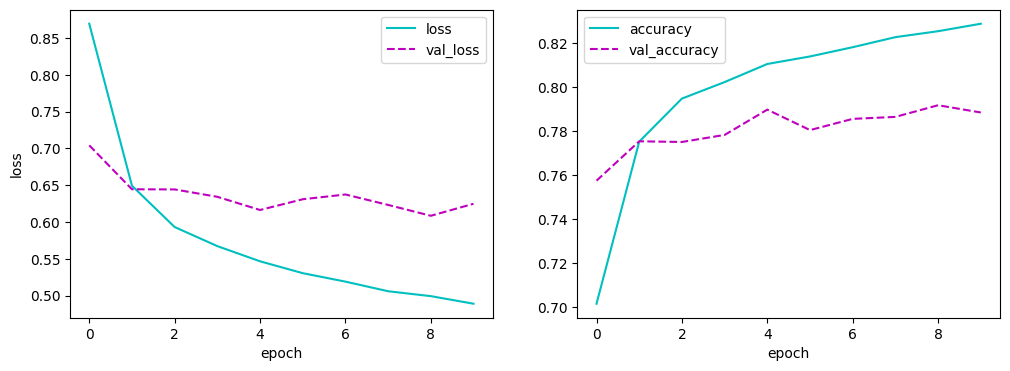

In [6]:
# 성능 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'c-', label='loss')
plt.plot(history.history['val_loss'], 'm--', label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'c-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'm--', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [8]:
# 미세 조정(Fine Tunning) - 전이 학습 이후 성능 향상을 위해 기존모델(백본)의 일부 층을 학습에 참여시킴
# optimizer는 원래의 기본값을 사용하면 안된다! - leaning_rate를 매우 적게 줘야함!

base_model.trainable = True # 모델 전체 학습에 참여 가능하게 열어 놓고
# 뒤에 10개의 층만 참여시킴 - 마지막 10개를 제외하고 동결
for layer in base_model.layers[:-10]:
  layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.000001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2, verbose=2)

loss , acc = model_tl.evaluate(x_test, y_test, verbose=0)
print(f'model_tl => loss :{loss:.4f}, acc :{acc:.4f}')

Epoch 1/10
625/625 - 36s - 57ms/step - accuracy: 0.5276 - loss: 2.0216 - val_accuracy: 0.7116 - val_loss: 0.9832
Epoch 2/10
625/625 - 15s - 24ms/step - accuracy: 0.6156 - loss: 1.4644 - val_accuracy: 0.6835 - val_loss: 1.1788
Epoch 3/10
625/625 - 15s - 24ms/step - accuracy: 0.6631 - loss: 1.2130 - val_accuracy: 0.6879 - val_loss: 1.1737
Epoch 4/10
625/625 - 15s - 24ms/step - accuracy: 0.6911 - loss: 1.0821 - val_accuracy: 0.6946 - val_loss: 1.1390
Epoch 5/10
625/625 - 15s - 24ms/step - accuracy: 0.7095 - loss: 0.9962 - val_accuracy: 0.7011 - val_loss: 1.0931
Epoch 6/10
625/625 - 15s - 24ms/step - accuracy: 0.7211 - loss: 0.9385 - val_accuracy: 0.7110 - val_loss: 1.0532
Epoch 7/10
625/625 - 15s - 24ms/step - accuracy: 0.7322 - loss: 0.8977 - val_accuracy: 0.7204 - val_loss: 1.0168
Epoch 8/10
625/625 - 15s - 24ms/step - accuracy: 0.7396 - loss: 0.8555 - val_accuracy: 0.7271 - val_loss: 0.9870
Epoch 9/10
625/625 - 15s - 24ms/step - accuracy: 0.7494 - loss: 0.8330 - val_accuracy: 0.7305 - 